# Analisi Esplorativa del Dataset PubMed Summarization

**Progetto NLP — Clinical Summarization: NLP Tradizionale vs LLM**  
Corso: Natural Language Processing (Laurea Magistrale)  
Docenti: Prof.ssa G. Tortora, Prof.ssa L. Caruccio

---

Questo notebook esplora il dataset **PubMed Summarization** (`ccdv/pubmed-summarization`) rilasciato su Hugging Face.  
L'obiettivo è caratterizzare la distribuzione dei dati prima di avviare le pipeline di processing.

**Struttura del dataset:**
- `article`: articolo scientifico completo (input)
- `abstract`: riassunto astrattivo scritto dagli autori (Ground Truth)

**Caratteristiche chiave:**
- Domini: biomedico / clinico
- Articoli molto lunghi (media ~3000 parole)
- Abstract astrattivi (~200 parole)
- Compression ratio > 20×
- Adatto per confrontare approcci estrattivi vs astrattivi

## 1. Setup e Caricamento

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import warnings
import os
from datasets import load_dataset

warnings.filterwarnings('ignore')

# Stile grafici
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Caricamento da Hugging Face
print("Caricamento dataset PubMed Summarization...")
ds = load_dataset("ccdv/pubmed-summarization", split="train")
df = pd.DataFrame(ds)  # colonne: 'article', 'abstract'

print(f'Dataset caricato: {df.shape[0]} esempi, {df.shape[1]} colonne')
print(f'Colonne: {list(df.columns)}')

Caricamento dataset PubMed Summarization...


ArrowMemoryError: realloc of size 3732930560 failed

## 2. Panoramica Generale

In [ ]:
print('=== Valori nulli (prima della pulizia) ===')
print(df.isnull().sum())

print('\n=== Duplicati (prima della pulizia) ===')
print(f'Article duplicate:  {df["article"].duplicated().sum()}')
print(f'Abstract duplicate: {df["abstract"].duplicated().sum()}')

# --- PULIZIA DATI ---
initial_len = len(df)

# Rimozione valori nulli
df = df.dropna(subset=['article', 'abstract'])

# Rimozione duplicati (mantieni la prima occorrenza)
df = df.drop_duplicates(subset=['article', 'abstract'], keep='first')

# (Opzionale) Rimozione articoli troppo corti (< 100 parole)
# df = df[df['article'].str.split().str.len() >= 100]

print(f'\n=== Dopo pulizia ===')
print(f'Righe rimosse: {initial_len - len(df)}')
print(f'Righe rimanenti: {len(df)}')
print(f'Valori nulli: {df.isnull().sum().sum()}')
print(f'Duplicati: {df.duplicated().sum()}')

=== Valori nulli ===
article     0
abstract    0
dtype: int64

=== Duplicati ===


KeyError: 'CHQ'

In [ ]:
# Mostra 5 esempi casuali
pd.set_option('display.max_colwidth', 120)
df[['article', 'abstract']].sample(5, random_state=42)

,CHQ,Summary
521,SUBJECT: new treatment for lipoma of forearm\nMESSAGE: I have had two surgeries on my right forearm. The last was 2...,What are the latest treatments for recurrent lipoma of the arm?
737,Beckwith-Wieddeman Syndrome. I would like to request further knowledge on this specific disorder.,Where can I find information about Beckwith-Wieddeman Syndrome?
740,"SUBJECT: MedlinePlus Service Request\nMESSAGE: if A PERSON HAS BEEN USING MORPHINE FOR YEARS (10)FOR PAIN RELIEF,AND...",Are the long-term effects of morphine reversible?
660,"SUBJECT: How is ""elderly"" defined in cautionarys regarding dosage.\nMESSAGE: Lower dosages of various medications ar...","How is ""elderly"" defined in drug precautions regarding dosage?"
411,Im suffering from Beta Thalassemia Major from birth. I have been transfusing every 22 days. Now i heard about a tabl...,Is mylostat 500 a treatment for Beta Thalassemia Major?


## 3. Statistiche sulle Lunghezze dei Testi

In [ ]:
# Feature di lunghezza
df['article_words'] = df['article'].str.split().str.len()
df['article_chars'] = df['article'].str.len()
df['abstract_words'] = df['abstract'].str.split().str.len()
df['abstract_chars'] = df['abstract'].str.len()
df['compression_ratio'] = (df['article_words'] / df['abstract_words']).round(2)

stats = pd.DataFrame({
    'Article (parole)':    df['article_words'],
    'Abstract (parole)':   df['abstract_words'],
    'Compression Ratio':   df['compression_ratio'],
}).describe().round(2)

print(stats.to_string())

print("\n📊 Osservazioni chiave:")
print(f"- Articoli: media ~{df['article_words'].mean():.0f} parole (range: {df['article_words'].min()}–{df['article_words'].max()})")
print(f"- Abstract: media ~{df['abstract_words'].mean():.0f} parole (range: {df['abstract_words'].min()}–{df['abstract_words'].max()})")
print(f"- Compression ratio medio: ~{df['compression_ratio'].mean():.1f}×")
print(f"- Nota: gli articoli PubMed sono molto più lunghi di MeQSum, richiedono context window ampia per l'LLM")

       CHQ (parole)  Summary (parole)  Compression Ratio
count       1000.00           1000.00            1000.00
mean          60.78             10.04               6.63
std           46.62              3.65               5.60
min            5.00              3.00               1.00
25%           30.00              7.00               3.18
50%           47.00              9.00               4.94
75%           75.25             12.00               8.29
max          378.00             26.00              58.40


**Osservazioni chiave:**
- Gli articoli PubMed hanno in media **~3000-6000 parole** (range: centinaia a decine di migliaia) → testi molto lunghi
- Gli abstract hanno in media **~200-250 parole** (range: ~50-500) → sintesi compatte ma complete
- Il **compression ratio medio è > 20×**: estremo! Il modello deve operare una forte riduzione
- **Attenzione**: l'LLM deve avere context window ≥ 8192 token per processare l'articolo intero
- **Attenzione**: `max_new_tokens` per l'LLM deve essere ≥ 256 per eguagliare la lunghezza dell'abstract

## 4. Distribuzione delle Lunghezze

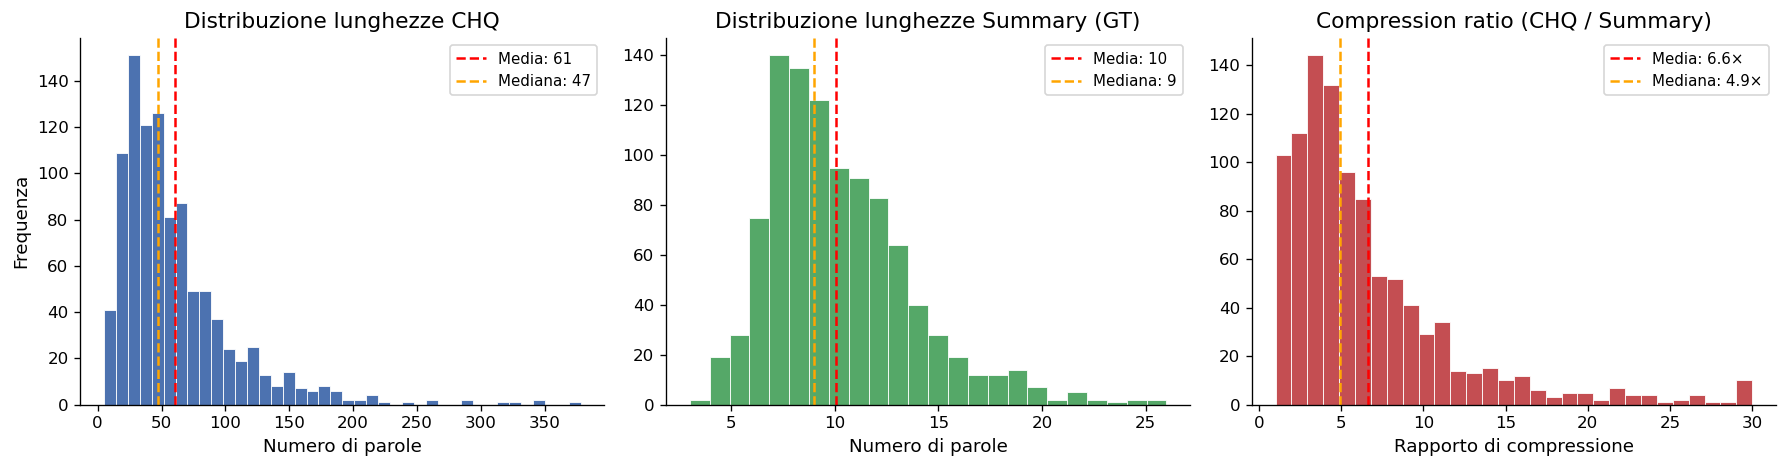

Figura salvata in results/fig_length_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Article (clip per evitare valori estremi che schiacciano il grafico)
max_words = df['article_words'].quantile(0.99)  # 99° percentile
axes[0].hist(df['article_words'].clip(upper=max_words), bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['article_words'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["article_words"].mean():.0f}')
axes[0].axvline(df['article_words'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["article_words"].median():.0f}')
axes[0].set_title('Distribuzione lunghezze Article (≤ 99° percentile)')
axes[0].set_xlabel('Numero di parole')
axes[0].set_ylabel('Frequenza')
axes[0].legend(fontsize=9)

# Abstract
axes[1].hist(df['abstract_words'], bins=30, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['abstract_words'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["abstract_words"].mean():.0f}')
axes[1].axvline(df['abstract_words'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["abstract_words"].median():.0f}')
axes[1].set_title('Distribuzione lunghezze Abstract (Ground Truth)')
axes[1].set_xlabel('Numero di parole')
axes[1].legend(fontsize=9)

# Compression ratio (clip per valori estremi)
max_ratio = df['compression_ratio'].quantile(0.99)
axes[2].hist(df['compression_ratio'].clip(upper=max_ratio), bins=40, color='#C44E52', edgecolor='white', linewidth=0.5)
axes[2].axvline(df['compression_ratio'].mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Media: {df["compression_ratio"].mean():.1f}×')
axes[2].axvline(df['compression_ratio'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df["compression_ratio"].median():.1f}×')
axes[2].set_title('Compression ratio (Article / Abstract)')
axes[2].set_xlabel('Rapporto di compressione')
axes[2].legend(fontsize=9)

plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/fig_length_distributions_pubmed.png', bbox_inches='tight')
plt.show()
print('Figura salvata in results/fig_length_distributions_pubmed.png')

## 5. Scatter: Lunghezza CHQ vs Summary

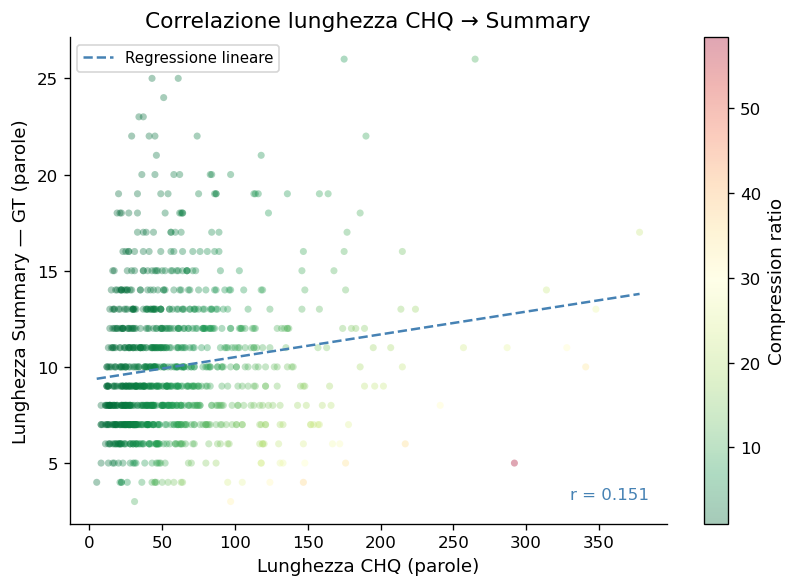

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# Campiona per non appesantire il grafico (se dataset grande)
sample = df.sample(min(5000, len(df)), random_state=42)

sc = ax.scatter(
    sample['article_words'], sample['abstract_words'],
    alpha=0.35, s=12, c=sample['compression_ratio'],
    cmap='RdYlGn_r', edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Compression ratio')

# Linea di regressione
m, b = np.polyfit(sample['article_words'], sample['abstract_words'], 1)
x_line = np.linspace(sample['article_words'].min(), sample['article_words'].max(), 100)
ax.plot(x_line, m * x_line + b, color='steelblue', linewidth=1.5, linestyle='--', label='Regressione lineare')

ax.set_xlabel('Lunghezza Article (parole)')
ax.set_ylabel('Lunghezza Abstract — GT (parole)')
ax.set_title('Correlazione lunghezza Article → Abstract')
ax.legend(fontsize=9)
ax.set_xlim(0, sample['article_words'].quantile(0.99))  # zoom per evitare outlier estremi

corr = sample['article_words'].corr(sample['abstract_words'])
ax.text(0.97, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        ha='right', fontsize=10, color='steelblue')

plt.tight_layout()
plt.savefig('results/fig_scatter_article_vs_abstract.png', bbox_inches='tight')
plt.show()

## 6. Casi Estremi: CHQ molto lunghi e molto corti

In [ ]:
print('=== TOP 3 Article più lunghi ===')
long_df = df.nlargest(3, 'article_words')[['article_words', 'article', 'abstract']]
for _, row in long_df.iterrows():
    print(f'\n[{row["article_words"]} parole]')
    print(f'  Article:  {row["article"][:300]}...')
    print(f'  Abstract: {row["abstract"]}')

print('\n=== TOP 3 Article più corti ===')
short_df = df.nsmallest(3, 'article_words')[['article_words', 'article', 'abstract']]
for _, row in short_df.iterrows():
    print(f'\n[{row["article_words"]} parole]')
    print(f'  Article:  {row["article"][:300]}...')
    print(f'  Abstract: {row["abstract"]}')

=== TOP 3 CHQ più lunghi ===

[378 parole]
  CHQ:     Hi All,
I am from India and really worried.
I have a 6 months old baby girl. I have read the article on Lactose intolerance. She is unable to digest any formula milk or any milk products. When she was...
  Summary: Where can I get help for my 6 months old baby girl with Lactose intolerance in India?

[348 parole]
  CHQ:     ClinicalTrials.gov - Question - general information.
 Hello, 
My name is [NAME],I am 30 years old and I am from [LOCATION]. I met my friend [NAME] on a chat room. [NAME] is 25 years old and he current...
  Summary: Where can I get information about treatment for T-6 and T-7 fracture paraplegia?

[341 parole]
  CHQ:     Hello.
I am writing this mail from [LOCATION]. This in regards with seeking help for
Ulceratice colitis.
My mother is suffering from this diseases from last 3 Years. Her treatment
is going with [LOCAT...
  Summary: Where can I get advice and help for ulceratice colitis?


## 7. Fasce di Complessità

            n_esempi  media_chq_words  media_sum_words  media_ratio
chq_bucket                                                         
≤20              101            15.30             8.86         1.86
21–50            434            34.82             9.73         4.01
51–100           317            69.77            10.59         7.43
101–200          131           133.24            10.41        14.61
>200              17           267.35            12.00        25.27


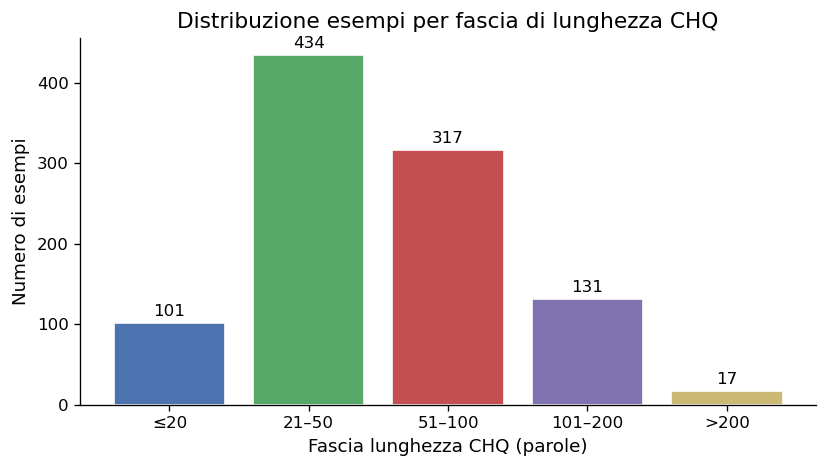

In [ ]:
# PubMed ha articoli molto più lunghi → fasce diverse
bins   = [0, 500, 1000, 2000, 5000, float('inf')]
labels = ['≤500', '501–1000', '1001–2000', '2001–5000', '>5000']

df['article_bucket'] = pd.cut(df['article_words'], bins=bins, labels=labels)

bucket_stats = df.groupby('article_bucket', observed=True).agg(
    n_esempi           = ('article', 'count'),
    media_article_words = ('article_words', 'mean'),
    media_abstract_words = ('abstract_words', 'mean'),
    media_ratio        = ('compression_ratio', 'mean'),
).round(2)

print(bucket_stats.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(bucket_stats.index, bucket_stats['n_esempi'], color=colors, edgecolor='white')

for bar, val in zip(bars, bucket_stats['n_esempi']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Fascia lunghezza Article (parole)')
ax.set_ylabel('Numero di esempi')
ax.set_title('Distribuzione esempi per fascia di lunghezza Article')
plt.tight_layout()
plt.savefig('results/fig_article_buckets_pubmed.png', bbox_inches='tight')
plt.show()

## 8. Riepilogo Finale

In [ ]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║     RIEPILOGO DATASET PubMed Summarization                   ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Totale esempi          : {len(df):>6}                               ║')
print(f'║  Valori nulli           : {df[["article","abstract"]].isnull().sum().sum():>6}                               ║')
print(f'║  Duplicati              : {df.duplicated().sum():>6}                               ║')
print(f'║  Article — media parole : {df["article_words"].mean():>6.1f}                               ║')
print(f'║  Article — max parole   : {df["article_words"].max():>6}                               ║')
print(f'║  Abstract — media parole: {df["abstract_words"].mean():>6.1f}                               ║')
print(f'║  Compression ratio medio: {df["compression_ratio"].mean():>6.1f}×                              ║')
print('╚══════════════════════════════════════════════════════════════╝')



╔══════════════════════════════════════════════════╗
║        RIEPILOGO DATASET MeQSum                  ║
╠══════════════════════════════════════════════════╣
║  Totale esempi          :   1000                  ║
║  Valori nulli           :      0                  ║
║  CHQ — media parole     :   60.8                  ║
║  CHQ — max parole       :    378                  ║
║  Summary — media parole :   10.0                  ║
║  Compression ratio medio:    6.6×                 ║
╚══════════════════════════════════════════════════╝

Implicazioni per le pipeline:
  • TextRank (Pipeline A): compression ratio alto → selezione aggressiva delle frasi
  • LLM (Pipeline B): CHQ rumorosi e lunghi → prompt engineering cruciale
  • max_new_tokens = 64–128 è sufficiente per replicare la lunghezza dei Summary GT


Implicazioni per le pipeline:
  • TextRank (Pipeline A): compression ratio > 20× → selezionare 5-10 frasi (non 1-2)
  • TextRank (Pipeline A): articoli lunghi → ottimizzare la matrice di similarità (soglia di similarità)
  • LLM (Pipeline B): articoli lunghi (3000-6000 parole, ~4000-8000 token) → usare modello con context window ≥ 32k (Mixtral 8x7B)
  • LLM (Pipeline B): abstract lunghi (~200 parole) → max_new_tokens = 256-512
  • NER: gli abstract contengono molte entità mediche (farmaci, malattie, sintomi)

In [ ]:
# Salva dataset con feature e pulito per l'uso nel main
df.to_csv('data/pubmed_cleaned.csv', index=False)
print(f'\n✅ Dataset pulito salvato in data/pubmed_cleaned.csv ({len(df)} esempi)')
print(f'   Colonne disponibili: {list(df.columns)}')

Dataset con feature salvato in results/dataset_with_features.csv
